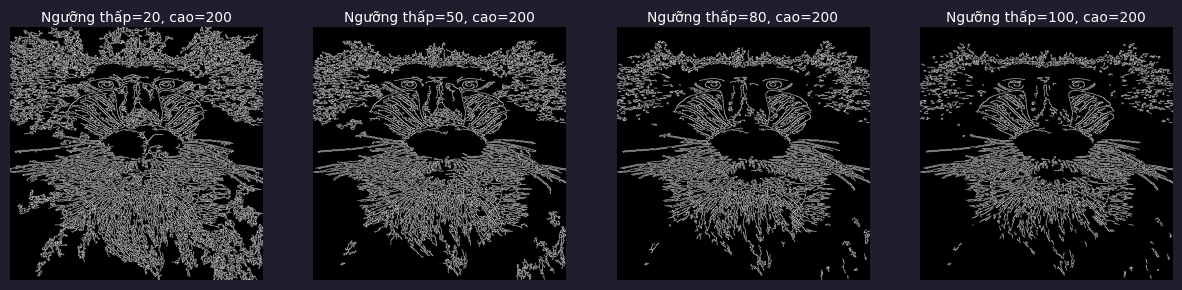

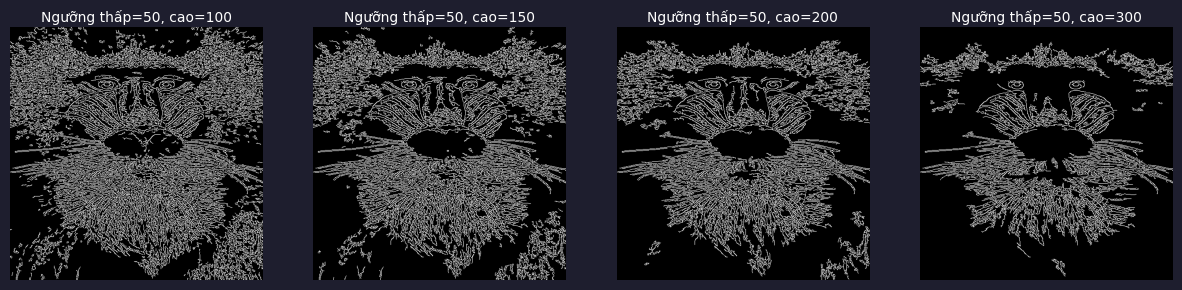

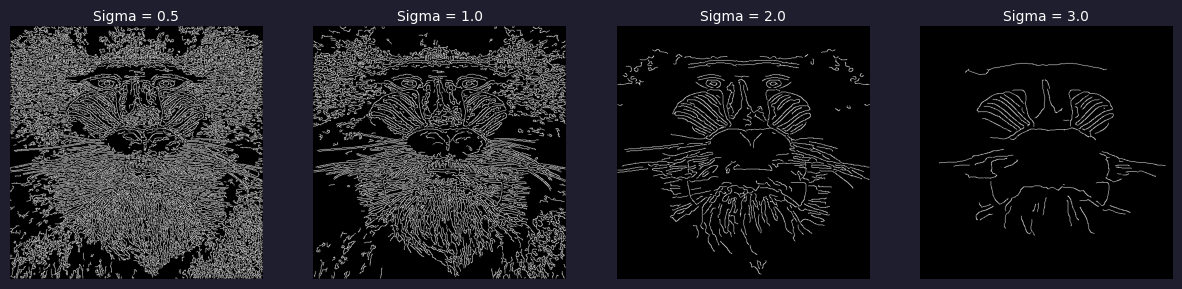

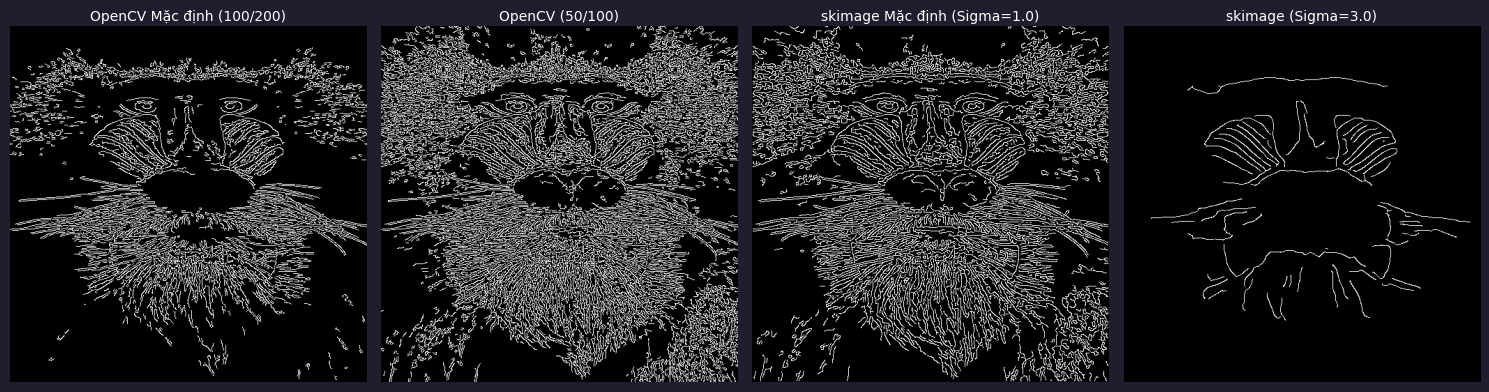

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import canny as skimage_canny

img = cv2.imread("../input/lab_image.jpg")
if img is None:
    print("Lỗi: Không tìm thấy ảnh tại ../input/lab_image.jpg")
else:

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (512, 512), interpolation=cv2.INTER_AREA)
    gray_f = img_gray.astype(np.float64) / 255.0

    def show(ax, img, title):
        ax.imshow(img, cmap="gray")
        ax.set_title(title, pad=4, fontsize=10, color="white")
        ax.axis("off")

    fig_bg = "#1e1e2e"

    # Thay đổi Ngưỡng Thấp (Giữ nguyên ngưỡng cao = 200)
    fig1, axes1 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)
    for ax, lo in zip(axes1, [20, 50, 80, 100]):
        edge = cv2.Canny(img_gray, lo, 200)
        show(ax, edge, f"Ngưỡng thấp={lo}, cao=200")
    plt.show()

    # Thay đổi Ngưỡng Cao (Giữ nguyên ngưỡng thấp = 50)
    fig2, axes2 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)
    for ax, hi in zip(axes2, [100, 150, 200, 300]):
        edge = cv2.Canny(img_gray, 50, hi)
        show(ax, edge, f"Ngưỡng thấp=50, cao={hi}")
    plt.show()

    #Thay đổi Sigma 
    fig3, axes3 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)
    for ax, sigma in zip(axes3, [0.5, 1.0, 2.0, 3.0]):
        edge = skimage_canny(gray_f, sigma=sigma)
        show(ax, edge, f"Sigma = {sigma}")
    plt.show()

    # SO SÁNH KẾT QUẢ VỚI GIÁ TRỊ MẶC ĐỊNH
    fig4, axes4 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)
    edge_cv2_def = cv2.Canny(img_gray, 100, 200)      
    edge_cv2_mod = cv2.Canny(img_gray, 50, 100)       
    edge_ski_def = skimage_canny(gray_f)              
    edge_ski_mod = skimage_canny(gray_f, sigma=3.0)    

    show(axes4[0], edge_cv2_def, "OpenCV Mặc định (100/200)")
    show(axes4[1], edge_cv2_mod, "OpenCV (50/100)")
    show(axes4[2], edge_ski_def, "skimage Mặc định (Sigma=1.0)")
    show(axes4[3], edge_ski_mod, "skimage (Sigma=3.0)")

    plt.tight_layout()
    plt.show()